# A routed lattice-surgery measurement: Z̄⊗Z̄ through a U-shaped corridor

One Pauli product measurement, Z̄₀Z̄₁, between two d×d surface-code patches placed two tiles apart.
The ancilla corridor runs up from each patch and across the row above, so the merged patch is
U-shaped.  The program is compiled with `compile_ppm_sequence`
([`circls/pipeline.py`](https://github.com/John-YuehanZhang/CircLS/blob/main/circls/pipeline.py)), which enters the compiler with a PPM sequence;
the patch cells, their orientations and the corridor are fixed with the `placement=`,
`orientation=` and `router=` hooks ([`docs/API_HOOKS.md`](https://github.com/John-YuehanZhang/CircLS/blob/main/docs/API_HOOKS.md)).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pymatching
import stim
from IPython.display import SVG, display

from circls.interop.ir.gosc_gadgets import OutBit, PPMProgram, ProgramOp
from circls.pipeline import compile_ppm_sequence
from circls.tools.evaluate import inject_uniform_noise


## 1. The program and its compilation

The program measures Z̄₀Z̄₁ and then reads both patches out in Z.  Both patches start in |0⟩, so all
three program bits are deterministic.  Section 2 lists the observables of the circuit.

* **Placement.**  Patch `q0` on coarse cell (0, 1) and `q1` on (2, 1).
* **Orientation.**  Both `X_vertical`: the corridor attaches on the north side of each patch, and a
  Z measurement through a north–south seam needs Z̄ to run along the seam.
* **Corridor.**  Cells (0, 0), (1, 0) and (2, 0), returned by the router hook for the one joint step.

In [2]:
program = PPMProgram(
    num_data=2,
    ops=[ProgramOp("mpp", {0: "Z", 1: "Z"}),    # the joint measurement Z0 Z1
         ProgramOp("mpp", {0: "Z"}),            # readout of q0
         ProgramOp("mpp", {1: "Z"})],           # readout of q1
    gadgets=[],
    out_bits=[OutBit(rec=k, flip=0) for k in range(3)],
)

PLACEMENT = {"q0": (0, 1), "q1": (2, 1)}
ORIENTATION = {"q0": "X_vertical", "q1": "X_vertical"}
CORRIDOR = [(0, 0), (1, 0), (2, 0)]

def u_corridor(live_specs, step):
    return CORRIDOR

def compile_routed_ppm(d):
    return compile_ppm_sequence(program, distance=d, placement=PLACEMENT,
                                orientation=ORIENTATION, router=u_corridor)

out = compile_routed_ppm(3)
c = out.circuit
print("PPM steps:", [s.interaction_type for s in out.experiment.ppm_sequence])
print("corridor:", out.routes[0])
print(f"{c.num_qubits} qubits, {c.num_ticks} ticks, {c.num_detectors} detectors, "
      f"{c.num_observables} observables")


PPM steps: [[('q0', 'Z'), ('q1', 'Z')]]
corridor: [(0, 0), (1, 0), (2, 0)]
111 qubits, 41 ticks, 166 detectors, 6 observables


## 2. The observables

The circuit has six `OBSERVABLE_INCLUDE` targets.  Three come from the syndrome tracker, which emits every
parity that checks a logical measurement outcome as an observable; three are the program bits, appended
by `compile_ppm_sequence`.  `m` is the Z̄₀Z̄₁ outcome, read from the product of the corridor Z checks.

| index | records | what it checks |
|---|---|---|
| 0 | corridor Z checks, first merge round | `m` against the prepared value Z̄₀Z̄₁ = +1 |
| 1 | corridor Z checks, last merge round, and the Z̄₀ and Z̄₁ readouts | the closure `m` ⊕ Z̄₀ ⊕ Z̄₁ = 0 |
| 2 | Z̄₀ readout | Z̄₀ against the prepared value +1 |
| 3 | corridor Z checks, last merge round | program bit 0 (`m`) |
| 4 | Z̄₀ readout | program bit 1 (Z̄₀) |
| 5 | corridor Z checks, last merge round, and the Z̄₁ readout | program bit 2 (Z̄₁) |

Observables 2 and 4 are the same record set, and observable 0 equals observable 3 up to detectors, so
three of the six are independent.  The closure (index 1) checks logical outcomes against each other,
so it is an observable and not a detector.

In [3]:
def summarize_observables(circuit):
    """For each observable: number of records and the ticks at which those records are measured."""
    tick, measured_at, obs = 0, [], {}
    for inst in circuit.flattened():
        if inst.name == "TICK":
            tick += 1
        elif inst.name == "OBSERVABLE_INCLUDE":
            k = int(inst.gate_args_copy()[0])
            obs.setdefault(k, set()).symmetric_difference_update(
                len(measured_at) + t.value for t in inst.targets_copy())
        elif inst.name not in ("DETECTOR", "QUBIT_COORDS", "SHIFT_COORDS") and stim.gate_data(inst.name).produces_measurements:
            measured_at += [tick] * len(inst.targets_copy())
    for k in sorted(obs):
        print(f"observable {k}: {len(obs[k]):2d} records, measured at ticks {sorted({measured_at[r] for r in obs[k]})}")

summarize_observables(c)

observable 0: 27 records, measured at ticks [17]
observable 1: 33 records, measured at ticks [39, 41]
observable 2:  3 records, measured at ticks [41]
observable 3: 27 records, measured at ticks [39]
observable 4:  3 records, measured at ticks [41]
observable 5: 30 records, measured at ticks [39, 41]


## 3. The merged patch

During the d merge rounds the two patches and the corridor form one patch.  The detector slice at
the start of the second merge round shows its stabilizers.

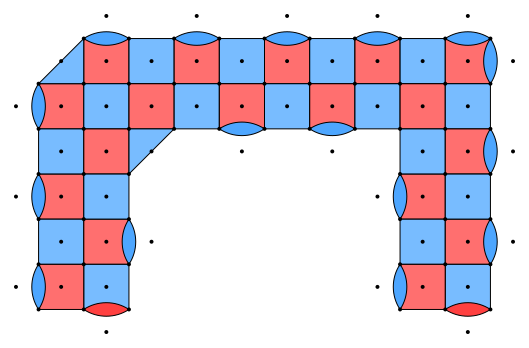

In [4]:
se_start = []                      # tick index at which each syndrome-extraction round starts
tick = 0
for inst in c.flattened():
    if inst.name == "TICK":
        if inst.tag == "SE_start":
            se_start.append(tick)
        tick += 1

display(SVG(str(c.diagram("detslice-svg", tick=se_start[1]))))


## 4. Detector slices

`circuit.diagram("detslice-with-ops-svg")` draws the whole d = 3 circuit tick by tick: the gates of
each tick and the detecting regions at that time.

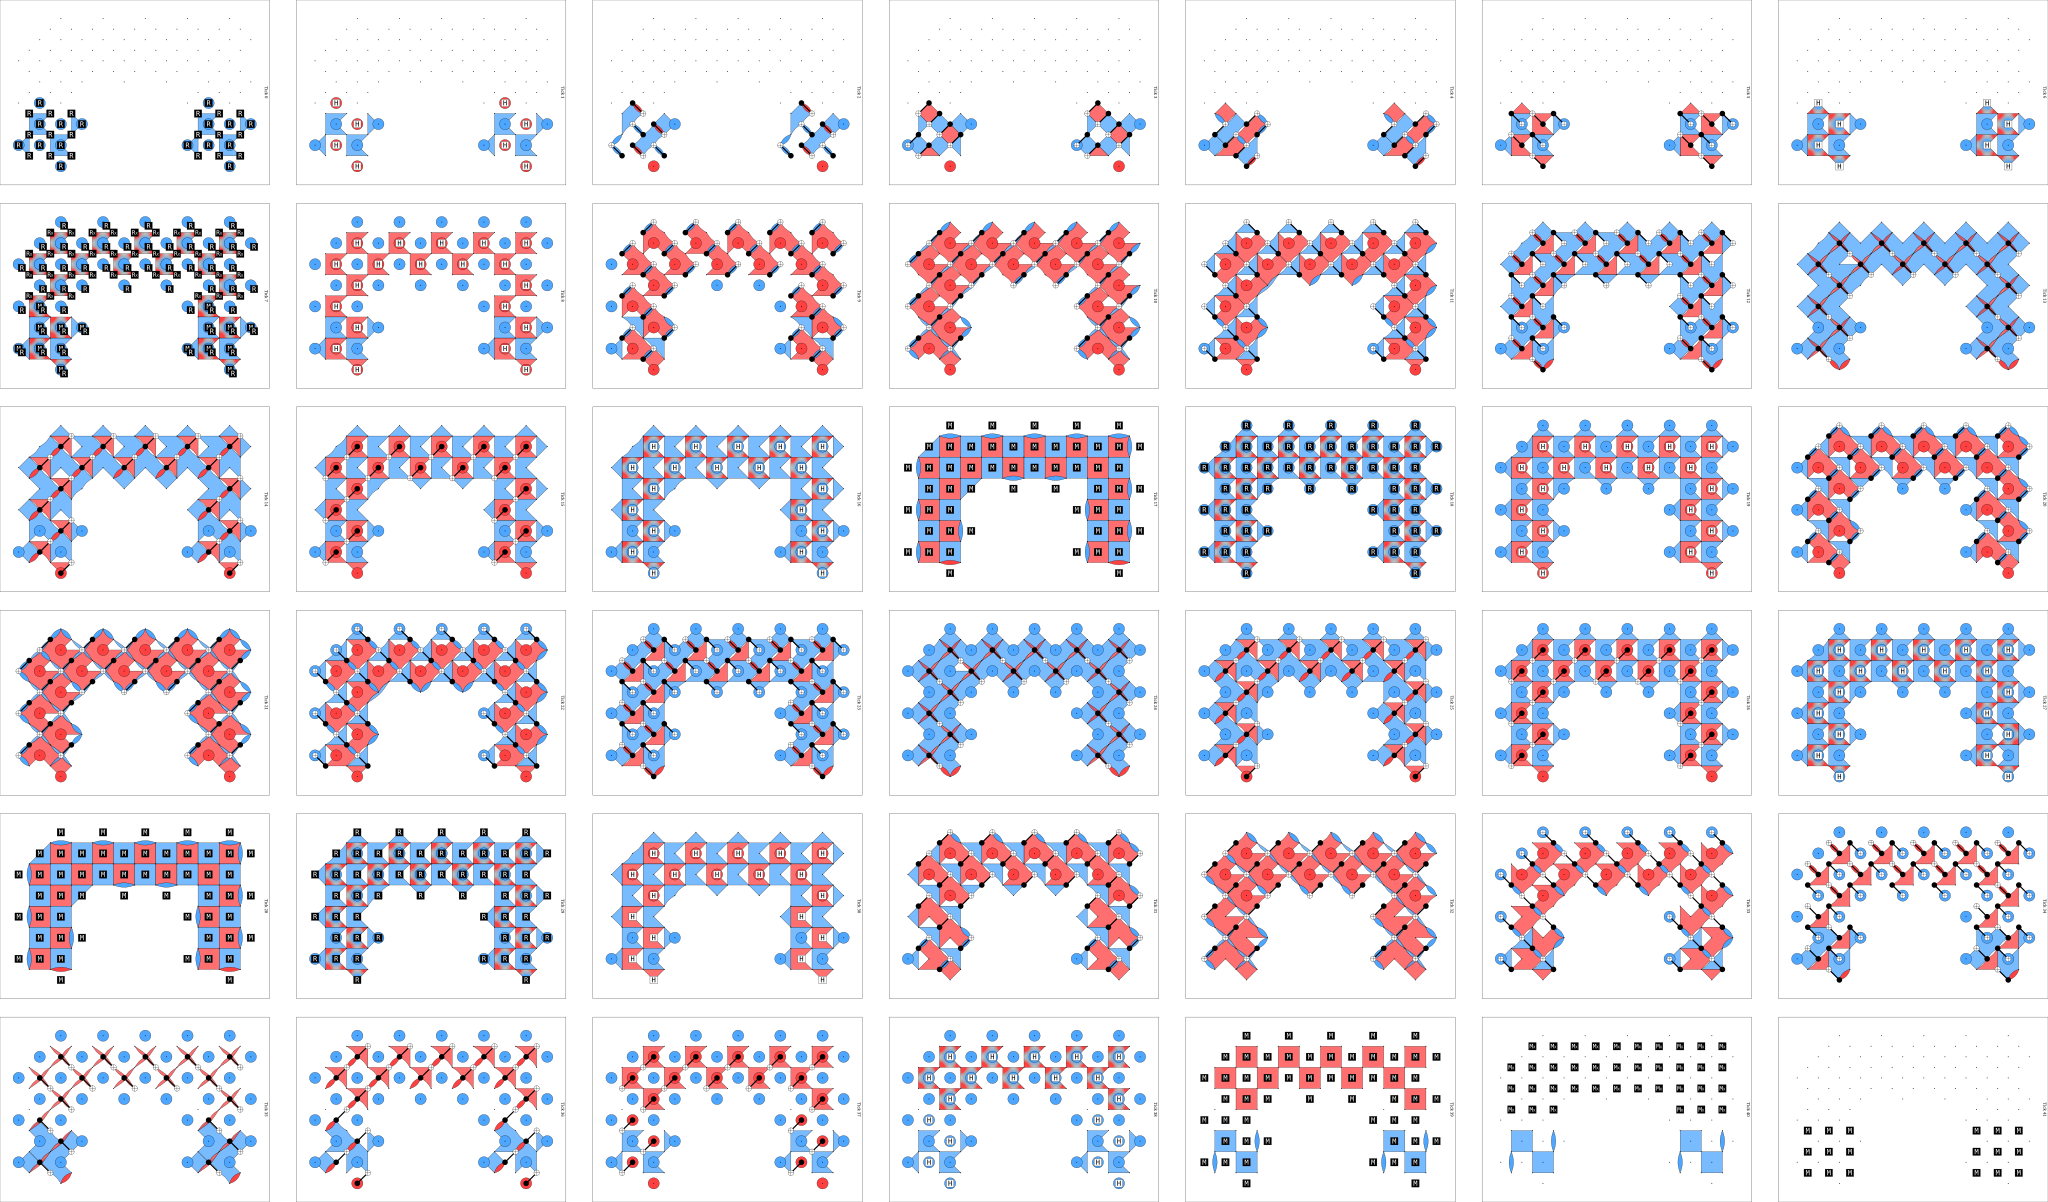

In [5]:
display(SVG(str(c.diagram("detslice-with-ops-svg"))))


## 5. Checks

At p = 0 no detector fires and every observable is deterministic.  Under the uniform circuit-level
depolarizing noise used throughout the CircLS paper (`inject_uniform_noise`), the shortest graphlike
logical error has length `d`.

In [6]:
for d in (3, 5, 7):
    circuit = compile_routed_ppm(d).circuit
    det, obs = circuit.compile_detector_sampler(seed=0).sample(256, separate_observables=True)
    noisy = inject_uniform_noise(circuit, 1e-3)
    print(f"d={d}: {circuit.num_qubits} qubits, {circuit.num_detectors} detectors, "
          f"p=0 silent={not det.any()}, deterministic={not obs.any()}, "
          f"graphlike distance={len(noisy.shortest_graphlike_error())}")


d=3: 111 qubits, 166 detectors, p=0 silent=True, deterministic=True, graphlike distance=3


d=5: 287 qubits, 740 detectors, p=0 silent=True, deterministic=True, graphlike distance=5


d=7: 543 qubits, 1962 detectors, p=0 silent=True, deterministic=True, graphlike distance=7


## 6. Logical error rate

Sample the noisy circuit and decode with PyMatching; a shot fails if any observable is wrong.  The six
observables include the closure, so a shot also fails when the decoder breaks `m` ⊕ Z̄₀ ⊕ Z̄₁ = 0.

In [7]:
def logical_error_rate(circuit, shots, seed=0):
    """Sample the noisy circuit and decode with PyMatching; returns (errors, shots)."""
    dem = circuit.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(dem)
    det, obs = circuit.compile_detector_sampler(seed=seed).sample(shots, separate_observables=True)
    errors = int(np.any(matcher.decode_batch(det) != obs, axis=1).sum())
    return errors, shots

p = 2e-3
for d in (3, 5, 7):
    noisy = inject_uniform_noise(compile_routed_ppm(d).circuit, p)
    errors, shots = logical_error_rate(noisy, shots=200_000)
    print(f"p={p:g} d={d}: LER = {errors / shots:.2e} ({errors}/{shots})")


p=0.002 d=3: LER = 9.71e-02 (19427/200000)


p=0.002 d=5: LER = 3.84e-02 (7680/200000)


p=0.002 d=7: LER = 1.56e-02 (3125/200000)
